# Actividad 5 — Visualización de Resultados con Validación Cruzada

### Curso: TC5057 · Análisis de Grandes Volúmenes de Datos
#### Tecnológico de Monterrey
##### Profesor Titular: Dr. Iván Olmos Pineda

---

| Nombre | Matrícula |
|--------|-----------|
| Diego Falcón Costilla | A01139580 |

---

Dataset: GTEx Analysis V10 — Gene Expression TPM (NIH / Broad Institute)  
Algoritmo base: Random Forest (PySpark MLlib) — mejor resultado Etapa 3  
Tarea: Clasificación multi-clase SMTSD · Subconjunto Nervioso (14 sub-tipos cerebrales)  
Referencia Etapa 3: Accuracy 0.7740 · F1-macro 0.7692

In [1]:
%matplotlib inline

import sys, os

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

_conda_env = os.path.dirname(sys.executable)
_java_home = os.path.join(_conda_env, 'Library', 'lib', 'jvm')
if os.path.isdir(_java_home):
    os.environ['JAVA_HOME'] = _java_home

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import FloatType

sys.path.insert(0, os.path.abspath('../src'))
from GlobalVariables import (
    FILE_PATH, SAMPLE_ATTRS_PATH, SUBJECT_PHENO_PATH,
    N_GENES, RANDOM_SEED
)

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

OUTPUT_DIR = os.path.abspath('../src/preliminary-analysis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'JAVA_HOME  : {os.environ.get("JAVA_HOME", "ERROR")}')
print(f'Semilla    : {RANDOM_SEED}')
print(f'Genes      : {N_GENES:,}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')

JAVA_HOME  : C:\Users\diego\anaconda3\envs\big-data\Library\lib\jvm
Semilla    : 42
Genes      : 59,033
OUTPUT_DIR : C:\Users\diego\projects\big-data\src\preliminary-analysis


In [2]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('GTEx_Actividad5_TC5057') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} · {spark.sparkContext.defaultParallelism} workers')

Spark 4.1.1 · 32 workers


In [3]:
# ── Carga de metadatos (misma lógica que Etapa 3) ──────────────────────────
sa_df = spark.read.csv(SAMPLE_ATTRS_PATH, sep='\t', header=True) \
    .select('SAMPID', 'SMTS', 'SMTSD', 'SMAFRZE') \
    .filter(F.col('SMAFRZE') == 'RNASEQ') \
    .withColumn('SUBJID', F.regexp_extract(F.col('SAMPID'), r'^(GTEX-[^-]+)', 1))

sp_df = spark.read.csv(SUBJECT_PHENO_PATH, sep='\t', header=True) \
    .select('SUBJID', 'SEX')

tissue_group_col = (
    F.when(F.col('SMTS').isin('Brain', 'Nerve'), 'Nervioso')
     .when(F.col('SMTS').isin('Blood', 'Bone Marrow', 'Spleen'), 'Hematopoyetico')
     .when(F.col('SMTS').isin('Heart', 'Blood Vessel'), 'Cardiovascular')
     .when(F.col('SMTS').isin('Muscle', 'Adipose Tissue', 'Skin'), 'Musculoesqueletico')
     .otherwise('Visceral_Metabolico')
)
sex_label_col = F.when(F.col('SEX') == '1', 'Masculino').otherwise('Femenino')

meta_df = sa_df.join(sp_df, on='SUBJID', how='inner') \
    .withColumn('TISSUE_GROUP', tissue_group_col) \
    .withColumn('SEX_LABEL', sex_label_col) \
    .withColumn('COL_NAME',
        F.regexp_replace(F.regexp_replace(F.col('SAMPID'), '-', '_'), '\\.', '_'))

print(f'Muestras RNASEQ: {meta_df.count():,}')

Muestras RNASEQ: 19,788


In [4]:
# ── Selección de top-500 genes por varianza (misma lógica que Etapa 3) ─────
CHUNK_SIZE  = 500
TOP_N_GENES = 500

peek = pd.read_csv(FILE_PATH, sep='\t', skiprows=2, nrows=0)
all_file_cols = peek.columns.tolist()

file_to_san = {
    c: c.replace('-', '_').replace('.', '_')
    for c in all_file_cols if c not in ('Name', 'Description')
}

meta_col_names = set(
    row['COL_NAME'] for row in meta_df.select('COL_NAME').collect()
)
valid_sample_cols_file = [c for c, san in file_to_san.items() if san in meta_col_names]
rename_dash_to_san     = {c: file_to_san[c] for c in valid_sample_cols_file}
usecols_file           = ['Name'] + valid_sample_cols_file

print(f'Calculando varianza para {N_GENES:,} genes...')
gene_vars = {}
for i, chunk in enumerate(pd.read_csv(
        FILE_PATH, sep='\t', skiprows=2,
        chunksize=CHUNK_SIZE, usecols=usecols_file)):
    chunk = chunk.rename(columns=rename_dash_to_san).set_index('Name')
    chunk = chunk.apply(pd.to_numeric, errors='coerce').fillna(0.0)
    gene_vars.update(chunk.var(axis=1).to_dict())
    if (i + 1) % 20 == 0:
        print(f'  bloque {i+1:>3} ({(i+1)*CHUNK_SIZE:,} genes)')

gene_var_series = pd.Series(gene_vars).sort_values(ascending=False)
top_gene_ids    = gene_var_series.head(TOP_N_GENES).index.tolist()
print(f'\nTop-{TOP_N_GENES} genes seleccionados.')

Calculando varianza para 59,033 genes...


  bloque  20 (10,000 genes)


  bloque  40 (20,000 genes)


  bloque  60 (30,000 genes)


  bloque  80 (40,000 genes)


  bloque 100 (50,000 genes)



Top-500 genes seleccionados.


In [5]:
# ── Carga de la matriz top-500 genes × todas las muestras ─────────────────
target_genes = set(top_gene_ids)
collected    = []

for chunk in pd.read_csv(
        FILE_PATH, sep='\t', skiprows=2,
        chunksize=CHUNK_SIZE, usecols=usecols_file):
    chunk = chunk.rename(columns=rename_dash_to_san)
    hit   = chunk[chunk['Name'].isin(target_genes)]
    if not hit.empty:
        collected.append(hit)

tpm_top = pd.concat(collected).set_index('Name')
tpm_top = tpm_top.apply(pd.to_numeric, errors='coerce').fillna(0.0)
print(f'Matriz TPM top genes: {tpm_top.shape[0]} genes × {tpm_top.shape[1]} muestras')

Matriz TPM top genes: 500 genes × 19616 muestras


In [6]:
# ── Construcción de M_nervioso (muestras × genes) ─────────────────────────
from sklearn.preprocessing import LabelEncoder

top_gene_ids_san = [g.replace('.', '_') for g in top_gene_ids if g in tpm_top.index]
tpm_top_san      = tpm_top.rename(index={g: g.replace('.', '_') for g in tpm_top.index})

tpm_T = tpm_top_san.loc[top_gene_ids_san].T.reset_index().rename(columns={'index': 'COL_NAME'})
gene_cols = [c for c in tpm_T.columns if c != 'COL_NAME']

meta_pd = meta_df.select('COL_NAME', 'TISSUE_GROUP', 'SEX_LABEL', 'SMTSD', 'SUBJID').toPandas()
M = tpm_T.merge(meta_pd, on='COL_NAME', how='inner').dropna(subset=['TISSUE_GROUP', 'SUBJID'])
M[gene_cols] = M[gene_cols].fillna(0.0)

M_nervioso = M[M['TISSUE_GROUP'] == 'Nervioso'].copy().dropna(subset=['SMTSD'])

le = LabelEncoder()
M_nervioso['label'] = le.fit_transform(M_nervioso['SMTSD'])

X       = M_nervioso[gene_cols].values
y       = M_nervioso['label'].values
groups  = M_nervioso['SUBJID'].values
classes = le.classes_
n_cls   = len(classes)

print(f'M_nervioso: {len(M_nervioso):,} muestras · {M_nervioso["SUBJID"].nunique():,} donantes · {n_cls} clases SMTSD')
print()
for i, name in enumerate(classes):
    print(f'  {i:>2}: {name} ({(y == i).sum():,} muestras)')

M_nervioso: 3,904 muestras · 786 donantes · 14 clases SMTSD

   0: Brain - Amygdala (181 muestras)
   1: Brain - Anterior cingulate cortex (BA24) (233 muestras)
   2: Brain - Caudate (basal ganglia) (300 muestras)
   3: Brain - Cerebellar Hemisphere (277 muestras)
   4: Brain - Cerebellum (266 muestras)
   5: Brain - Cortex (270 muestras)
   6: Brain - Frontal Cortex (BA9) (269 muestras)
   7: Brain - Hippocampus (255 muestras)
   8: Brain - Hypothalamus (257 muestras)
   9: Brain - Nucleus accumbens (basal ganglia) (285 muestras)
  10: Brain - Putamen (basal ganglia) (254 muestras)
  11: Brain - Spinal cord (cervical c-1) (204 muestras)
  12: Brain - Substantia nigra (183 muestras)
  13: Nerve - Tibial (670 muestras)


In [7]:
# ── Preprocesamiento: StandardScaler + PCA (misma config que Etapa 3) ─────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

N_PCA = 50

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X)

pca     = SklearnPCA(n_components=N_PCA, random_state=RANDOM_SEED)
X_pca   = pca.fit_transform(X_sc)

cum_var = pca.explained_variance_ratio_.cumsum()
print(f'Varianza acumulada PC1-{N_PCA}: {cum_var[-1]*100:.1f}%')
print(f'X_pca shape: {X_pca.shape}')

Varianza acumulada PC1-50: 87.0%
X_pca shape: (3904, 50)


---
## 1. Cálculo del valor K para validación cruzada

### 1.1 Planteamiento del problema

Partiendo de la muestra $M = \{M_i : M_i \text{ es una partición de TISSUE\_GROUP} \times \text{SEX\_LABEL}\}$ definida en Etapa 3, se trabaja sobre el subconjunto Nervioso con:

- $|M_{\text{Nervioso}}| = 3{,}904$ muestras RNASEQ
- $|D_{\text{Nervioso}}| = 786$ donantes únicos
- 14 sub-tipos SMTSD (clases objetivo)

La validación cruzada de $k$-fold divide la muestra en $k$ pliegues mutuamente excluyentes. En cada iteración, $k-1$ pliegues se usan para entrenamiento y 1 para prueba, rotando hasta que cada pliegue haya sido test exactamente una vez. El estimador de error final es:

$$\hat{\varepsilon}_{CV} = \frac{1}{k} \sum_{j=1}^{k} \varepsilon_j$$

### 1.2 Restricciones para determinar K

#### R1 — Representatividad estadística por clase

Para que cada pliegue de prueba sea una muestra representativa, cada clase debe estar suficientemente representada. La regla empírica requiere al menos $n_{\min} = 30$ instancias por clase en el conjunto de prueba de cada fold.

Sea $C_{\min}$ la cardinalidad de la clase más pequeña. Entonces:
$$k \leq \left\lfloor \frac{C_{\min}}{n_{\min}} \right\rfloor$$

#### R2 — División por donante (GroupKFold)

Dado que un mismo donante puede aportar muestras de varias regiones cerebrales, la unidad de división debe ser el donante (SUBJID), no la muestra. Esto garantiza $T_{r_j} \cap T_{s_j} = \emptyset$ a nivel de individuo. Con $|D| = 786$ donantes:
$$k \leq |D| = 786$$

#### R3 — Costo computacional (Big Data)

Cada fold implica un entrenamiento completo de Random Forest sobre PySpark. El costo es $O(k \cdot T_{\text{train}})$. Para $k$ grande, el costo de experimentación crece linealmente. En el contexto de Big Data, se prefiere minimizar $k$ siempre que se mantenga representatividad.

#### R4 — Sesgo-varianza del estimador CV

- $k$ pequeño (p.ej. $k=2$): alto sesgo en la estimación (el conjunto de entrenamiento es solo 50% de los datos).
- $k$ grande (p.ej. $k=10$, $k=N$): baja varianza del estimador pero mayor costo computacional y mayor varianza entre folds por conjuntos de prueba pequeños.
- $k=5$ y $k=10$ son los valores de la literatura que mejor equilibran sesgo, varianza y costo (Kohavi, 1995; Hastie et al., 2009).

In [8]:
# ── Cálculo cuantitativo del valor K ───────────────────────────────────────
class_counts = pd.Series(y).value_counts().sort_index()
c_min        = class_counts.min()
c_min_name   = classes[class_counts.idxmin()]
n_donors     = M_nervioso['SUBJID'].nunique()
n_min_req    = 30  # mínimo estadístico por clase en test

k_max_r1 = int(c_min // n_min_req)
k_chosen = 5

print('=== Análisis para determinar K ===')
print(f'Muestras totales          : {len(y):,}')
print(f'Donantes únicos           : {n_donors:,}')
print(f'Clases (sub-tipos SMTSD)  : {n_cls}')
print(f'Clase más pequeña         : "{c_min_name}" ({c_min} muestras)')
print()
print(f'R1 — mín. {n_min_req} muestras/clase/fold → K ≤ {k_max_r1}')
print(f'R2 — GroupKFold por donante → K ≤ {n_donors}')
print(f'R3 — costo computacional (Big Data) → minimizar K')
print(f'R4 — sesgo-varianza → K ∈ {{5, 10}} (literatura)')
print()
print(f'K elegido: {k_chosen}')
print()
print('Verificación con K=5:')
for i, name in enumerate(classes):
    n_total = (y == i).sum()
    n_test_est = n_total // k_chosen
    ok = '✓' if n_test_est >= n_min_req else '✗'
    print(f'  {ok} {name:<45} total={n_total:>4}  test/fold≈{n_test_est:>3}')

=== Análisis para determinar K ===
Muestras totales          : 3,904
Donantes únicos           : 786
Clases (sub-tipos SMTSD)  : 14
Clase más pequeña         : "Brain - Amygdala" (181 muestras)

R1 — mín. 30 muestras/clase/fold → K ≤ 6
R2 — GroupKFold por donante → K ≤ 786
R3 — costo computacional (Big Data) → minimizar K
R4 — sesgo-varianza → K ∈ {5, 10} (literatura)

K elegido: 5

Verificación con K=5:
  ✓ Brain - Amygdala                              total= 181  test/fold≈ 36
  ✓ Brain - Anterior cingulate cortex (BA24)      total= 233  test/fold≈ 46
  ✓ Brain - Caudate (basal ganglia)               total= 300  test/fold≈ 60
  ✓ Brain - Cerebellar Hemisphere                 total= 277  test/fold≈ 55
  ✓ Brain - Cerebellum                            total= 266  test/fold≈ 53
  ✓ Brain - Cortex                                total= 270  test/fold≈ 54
  ✓ Brain - Frontal Cortex (BA9)                  total= 269  test/fold≈ 53
  ✓ Brain - Hippocampus                           total= 255

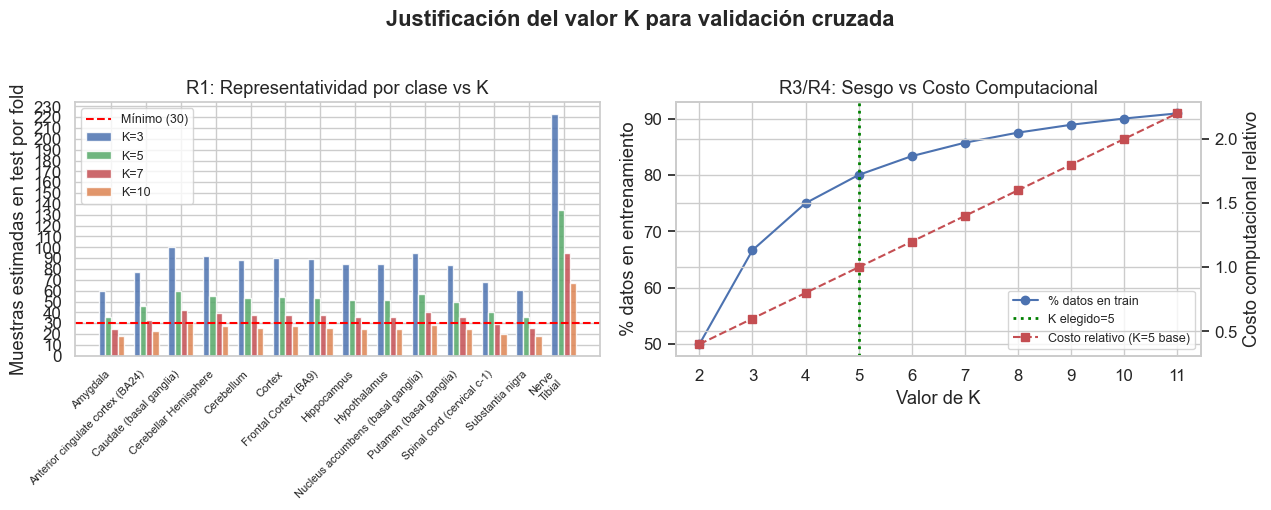

K = 5 elegido: cumple representatividad (R1), controlable computacionalmente (R3) y equilibrio sesgo-varianza (R4).


In [9]:
# ── Visualización comparativa de valores K candidatos ────────────────────
k_candidates = [3, 5, 7, 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: muestras de prueba estimadas por clase para cada K
ax1 = axes[0]
x_pos = np.arange(n_cls)
width = 0.18
colors = ['#4c72b0', '#55a868', '#c44e52', '#dd8452']

for idx, k in enumerate(k_candidates):
    n_tests = [int((y == i).sum() // k) for i in range(n_cls)]
    ax1.bar(x_pos + idx * width, n_tests, width=width, label=f'K={k}', color=colors[idx], alpha=0.85)

ax1.axhline(n_min_req, color='red', linestyle='--', linewidth=1.5, label=f'Mínimo ({n_min_req})')
ax1.set_xticks(x_pos + 1.5 * width)
ax1.set_xticklabels([c.replace('Brain - ', '').replace('Nerve - ', 'Nerve\n') for c in classes],
                    rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Muestras estimadas en test por fold')
ax1.set_title('R1: Representatividad por clase vs K')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(10))

# Panel derecho: sesgo esperado vs costo relativo
ax2 = axes[1]
all_k     = list(range(2, 12))
train_pct = [(k - 1) / k * 100 for k in all_k]
cost_rel  = [k / 5 for k in all_k]  # relativo a K=5

ax2_r = ax2.twinx()
ax2.plot(all_k, train_pct, 'o-', color='#4c72b0', label='% datos en train')
ax2_r.plot(all_k, cost_rel, 's--', color='#c44e52', label='Costo relativo (K=5 base)')
ax2.axvline(k_chosen, color='green', linestyle=':', linewidth=2, label=f'K elegido={k_chosen}')
ax2.set_xlabel('Valor de K')
ax2.set_ylabel('% datos en entrenamiento')
ax2_r.set_ylabel('Costo computacional relativo')
ax2.set_title('R3/R4: Sesgo vs Costo Computacional')
ax2.set_xticks(all_k)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle('Justificación del valor K para validación cruzada', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_k_justification.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K = {k_chosen} elegido: cumple representatividad (R1), controlable computacionalmente (R3) y equilibrio sesgo-varianza (R4).')

### 1.3 Conclusión justificada del valor K

Se elige K = 5 con las siguientes justificaciones:

| Restricción | K=3 | K=5 | K=7 | K=10 |
|-------------|-----|-----|-----|------|
| R1: ≥30 muestras/clase en test | ✓ (holgado) | ✓ | ✓ (ajustado en Amígdala y N. nigra) | ✗ (18 muestras en clases minoritarias) |
| R3: costo computacional | 0.6× | 1.0× | 1.4× | 2.0× |
| R4: sesgo-varianza | Alto sesgo (67% train) | Equilibrado (80% train) | Bueno | Bajo sesgo pero mayor costo |
| R2: GroupKFold factible | ✓ | ✓ | ✓ | ✓ |

K=5 garantiza que:
- Cada fold de prueba contiene aproximadamente $3{,}904 / 5 \approx 781$ muestras y mínimo $\approx 36$ muestras de la clase más pequeña (Brain - Amygdala, 181 instancias totales), superando el umbral estadístico de 30.
- El conjunto de entrenamiento (4 pliegues = 80%) es suficientemente grande para que el Random Forest aprenda los patrones moleculares de las 14 regiones cerebrales.
- El costo de experimentación (5 entrenamientos) es manejable en el contexto Big Data del sistema GTEx V10.
- La división se realiza por donante (GroupKFold con SUBJID), manteniendo la invariante $T_{r_j} \cap T_{s_j} = \emptyset$ requerida para evaluar generalización real a individuos no vistos.

Referencia: Kohavi, R. (1995). *A study of cross-validation and bootstrap for accuracy estimation and model selection*. IJCAI. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.), Springer.

---
## 2. Construcción de los k-folds

Se utiliza GroupKFold(n_splits=5) de scikit-learn, que divide los donantes (SUBJID) en 5 grupos mutuamente excluyentes. Esta estrategia:

1. Preserva el proceso de muestreo definido en Etapa 2/3: las 10 particiones $M_i = \text{TISSUE\_GROUP} \times \text{SEX\_LABEL}$ ya garantizan la representatividad de la muestra original. Al dividir por donante, se extiende esa representatividad a cada fold.
2. Evita fuga de datos (data leakage): ningún donante aparece simultáneamente en entrenamiento y prueba dentro de un fold.
3. Escala a Big Data: GroupKFold genera índices de partición sin copiar datos — solo los índices se distribuyen, y PySpark maneja el entrenamiento en cada fold de forma distribuida.

 Nota sobre estratificación: GroupKFold no estratifica por clase, ya que la restricción por grupo (donante) es dominante. Con 786 donantes distribuidos entre 14 regiones cerebrales (cada donante aporta muestras de múltiples regiones), la distribución por clase se mantiene aproximadamente uniforme entre folds por la diversidad de donantes.

In [10]:
from sklearn.model_selection import GroupKFold

K = 5
gkf  = GroupKFold(n_splits=K)
fold_splits = list(gkf.split(X_pca, y, groups=groups))

print(f'=== Estructura de los {K} folds (GroupKFold por donante) ===')
print(f'{"Fold":<6} {"Train N":>8} {"Test N":>8} {"Train Donors":>14} {"Test Donors":>13} {"Overlap":>9}')
print('-' * 65)

for fold_idx, (tr_idx, ts_idx) in enumerate(fold_splits):
    tr_donors = set(groups[tr_idx])
    ts_donors = set(groups[ts_idx])
    overlap   = len(tr_donors & ts_donors)
    print(f'{fold_idx+1:<6} {len(tr_idx):>8,} {len(ts_idx):>8,} {len(tr_donors):>14,} {len(ts_donors):>13,} {overlap:>9}')

print()
print('Overlap = 0 en todos los folds → división por donante correcta.')

=== Estructura de los 5 folds (GroupKFold por donante) ===
Fold    Train N   Test N   Train Donors   Test Donors   Overlap
-----------------------------------------------------------------
1         3,123      781            629           157         0
2         3,123      781            629           157         0
3         3,123      781            629           157         0
4         3,123      781            628           158         0
5         3,124      780            629           157         0

Overlap = 0 en todos los folds → división por donante correcta.


In [11]:
# ── Distribución de clases por fold ───────────────────────────────────────
fold_class_dist = np.zeros((K, n_cls), dtype=int)

for fold_idx, (_, ts_idx) in enumerate(fold_splits):
    for cls_idx in range(n_cls):
        fold_class_dist[fold_idx, cls_idx] = (y[ts_idx] == cls_idx).sum()

fold_df = pd.DataFrame(
    fold_class_dist,
    index=[f'Fold {i+1}' for i in range(K)],
    columns=[c.replace('Brain - ', '').replace('Nerve - ', 'Nerve - ') for c in classes]
)

print('Muestras por clase en el conjunto de prueba de cada fold:')
print(fold_df.to_string())
print()
print(f'Mínimo en cualquier celda: {fold_class_dist.min()} (debe ser ≥30)')

Muestras por clase en el conjunto de prueba de cada fold:
        Amygdala  Anterior cingulate cortex (BA24)  Caudate (basal ganglia)  Cerebellar Hemisphere  Cerebellum  Cortex  Frontal Cortex (BA9)  Hippocampus  Hypothalamus  Nucleus accumbens (basal ganglia)  Putamen (basal ganglia)  Spinal cord (cervical c-1)  Substantia nigra  Nerve - Tibial
Fold 1        36                                50                       64                     53          51      55                    58           52            46                                 55                       51                          43                34             133
Fold 2        36                                46                       60                     56          55      53                    53           48            54                                 58                       55                          39                35             133
Fold 3        40                                47                      

In [12]:
# ── Gráfica: distribución de clases por fold ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fold_df.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.axhline(30, color='red', linestyle='--', linewidth=1.5, label='Mínimo requerido (30)')
ax.set_xlabel('Sub-tipo SMTSD')
ax.set_ylabel('Muestras en conjunto de prueba')
ax.set_title(f'Distribución de clases en el conjunto de prueba — {K}-fold (GroupKFold por donante)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.legend(title='Fold', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_fold_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Experimentación con Validación Cruzada

### 3.1 Algoritmo seleccionado

El Random Forest (PySpark MLlib RandomForestClassifier) reportó el mejor resultado en Etapa 3 con Accuracy 0.7740 y F1-macro 0.7692 sobre 14 sub-tipos cerebrales. Los mismos hiperparámetros se mantienen para garantizar comparabilidad:

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| numTrees | 100 | Equilibrio estabilidad/cómputo |
| maxDepth | 10 | Limita sobreajuste |
| featureSubsetStrategy | sqrt | Estándar clasificación; √50 ≈ 7 PCs/árbol |
| seed | 42 | Reproducibilidad |

Pipeline por fold:
1. Extraer X_train, X_test, y_train, y_test a partir de los índices del fold
2. Crear DataFrames Spark con las 50 componentes PCA
3. Ensamblar vector de features con VectorAssembler
4. Entrenar RandomForestClassifier
5. Evaluar con MulticlassClassificationEvaluator (accuracy, F1-macro)
6. Calcular métricas por clase con sklearn.classification_report
7. Registrar resultados en listas para posterior visualización

### 3.2 Métricas registradas

- Accuracy global por fold
- F1-macro por fold
- Precision, Recall, F1 por clase por fold
- Matriz de confusión por fold
- Importancia de features (PCs) por fold

In [13]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report, confusion_matrix

pca_cols = [f'pc{i:02d}' for i in range(N_PCA)]

def build_spark_df(X_pca_arr, y_arr):
    df = pd.DataFrame(X_pca_arr, columns=pca_cols)
    df['label'] = y_arr.astype(float)
    sdf = spark.createDataFrame(df)
    asm = VectorAssembler(inputCols=pca_cols, outputCol='features')
    return asm.transform(sdf).select('features', 'label')

acc_eval = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy')
f1_eval  = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1')

print('Funciones de apoyo definidas.')

Funciones de apoyo definidas.


In [14]:
# ── Loop de validación cruzada ─────────────────────────────────────────────
results = []

for fold_idx, (tr_idx, ts_idx) in enumerate(fold_splits):
    X_tr, X_ts = X_pca[tr_idx], X_pca[ts_idx]
    y_tr, y_ts = y[tr_idx],     y[ts_idx]

    train_sdf = build_spark_df(X_tr, y_tr).cache()
    test_sdf  = build_spark_df(X_ts, y_ts)

    rf = SparkRF(
        labelCol='label', featuresCol='features',
        numTrees=100, maxDepth=10,
        featureSubsetStrategy='sqrt', seed=RANDOM_SEED
    )

    print(f'  Fold {fold_idx+1}/{K} — entrenando RF ({len(y_tr):,} train | {len(y_ts):,} test)...')
    rf_model = rf.fit(train_sdf)

    preds_sdf = rf_model.transform(test_sdf)
    acc = acc_eval.evaluate(preds_sdf)
    f1  = f1_eval.evaluate(preds_sdf)

    preds_pd = preds_sdf.select('label', 'prediction').toPandas()
    y_true   = preds_pd['label'].astype(int).values
    y_pred   = preds_pd['prediction'].astype(int).values

    report   = classification_report(
        y_true, y_pred, target_names=classes,
        output_dict=True, zero_division=0
    )
    cm       = confusion_matrix(y_true, y_pred, labels=list(range(n_cls)))
    feat_imp = rf_model.featureImportances.toArray()

    results.append({
        'fold':      fold_idx + 1,
        'acc':       acc,
        'f1':        f1,
        'report':    report,
        'cm':        cm,
        'feat_imp':  feat_imp,
        'n_train':   len(y_tr),
        'n_test':    len(y_ts),
    })

    train_sdf.unpersist()
    print(f'    Accuracy={acc:.4f}  F1-macro={f1:.4f}')

print()
print('Validación cruzada completada.')

  Fold 1/5 — entrenando RF (3,123 train | 781 test)...


    Accuracy=0.7567  F1-macro=0.7533


  Fold 2/5 — entrenando RF (3,123 train | 781 test)...


    Accuracy=0.7606  F1-macro=0.7585


  Fold 3/5 — entrenando RF (3,123 train | 781 test)...


    Accuracy=0.7695  F1-macro=0.7641


  Fold 4/5 — entrenando RF (3,123 train | 781 test)...


    Accuracy=0.7810  F1-macro=0.7800


  Fold 5/5 — entrenando RF (3,124 train | 780 test)...


    Accuracy=0.7936  F1-macro=0.7929

Validación cruzada completada.


In [15]:
# ── Tabla resumen por fold ────────────────────────────────────────────────
acc_values = [r['acc'] for r in results]
f1_values  = [r['f1']  for r in results]

print('=== Resultados por fold ===')
print(f'{"Fold":<6} {"Accuracy":>10} {"F1-macro":>10} {"Train N":>9} {"Test N":>8}')
print('-' * 48)
for r in results:
    print(f'{r["fold"]:<6} {r["acc"]:>10.4f} {r["f1"]:>10.4f} {r["n_train"]:>9,} {r["n_test"]:>8,}')
print('-' * 48)
print(f'{"Media":<6} {np.mean(acc_values):>10.4f} {np.mean(f1_values):>10.4f}')
print(f'{"Std":<6} {np.std(acc_values):>10.4f} {np.std(f1_values):>10.4f}')
print(f'{"Min":<6} {np.min(acc_values):>10.4f} {np.min(f1_values):>10.4f}')
print(f'{"Max":<6} {np.max(acc_values):>10.4f} {np.max(f1_values):>10.4f}')
print()
print(f'Referencia Etapa 3 (single split): Accuracy=0.7740  F1-macro=0.7692')

=== Resultados por fold ===
Fold     Accuracy   F1-macro   Train N   Test N
------------------------------------------------
1          0.7567     0.7533     3,123      781
2          0.7606     0.7585     3,123      781
3          0.7695     0.7641     3,123      781
4          0.7810     0.7800     3,123      781
5          0.7936     0.7929     3,124      780
------------------------------------------------
Media      0.7723     0.7698
Std        0.0135     0.0146
Min        0.7567     0.7533
Max        0.7936     0.7929

Referencia Etapa 3 (single split): Accuracy=0.7740  F1-macro=0.7692


---
## 4. Resultados de la Validación Cruzada

Las siguientes gráficas presentan los resultados de los 5 experimentos de validación cruzada. Cada visualización responde una pregunta específica sobre la calidad y variabilidad del modelo.

In [16]:
# ── Gráfica 1: Accuracy y F1-macro por fold con línea de referencia ───────
folds  = [r['fold'] for r in results]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(folds, acc_values, 'o-', color='#4c72b0', linewidth=2, markersize=8, label='Accuracy')
ax.plot(folds, f1_values,  's--', color='#55a868', linewidth=2, markersize=8, label='F1-macro')

ax.axhline(np.mean(acc_values), color='#4c72b0', linestyle=':', alpha=0.7,
           label=f'Media Accuracy ({np.mean(acc_values):.4f})')
ax.axhline(np.mean(f1_values),  color='#55a868', linestyle=':', alpha=0.7,
           label=f'Media F1-macro ({np.mean(f1_values):.4f})')
ax.axhline(0.7740, color='gray', linestyle='-.', linewidth=1.2, alpha=0.8,
           label='Referencia Etapa 3 (0.7740)')

for i, (f, a, f1) in enumerate(zip(folds, acc_values, f1_values)):
    ax.annotate(f'{a:.3f}', (f, a), textcoords='offset points', xytext=(0, 10), fontsize=9, color='#4c72b0')
    ax.annotate(f'{f1:.3f}', (f, f1), textcoords='offset points', xytext=(0, -16), fontsize=9, color='#55a868')

ax.fill_between(folds,
                [np.mean(acc_values) - np.std(acc_values)] * K,
                [np.mean(acc_values) + np.std(acc_values)] * K,
                alpha=0.12, color='#4c72b0', label='±1 std Accuracy')

ax.set_xticks(folds)
ax.set_xlabel('Fold')
ax.set_ylabel('Métrica')
ax.set_title(f'Accuracy y F1-macro por fold — RF 5-fold CV (GroupKFold, {n_cls} clases SMTSD Nervioso)')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0.65, 0.90)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_acc_f1_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Gráfica 2: Boxplot de métricas globales y por clase ───────────────────
per_class_f1 = {
    cls: [r['report'][cls]['f1-score'] for r in results]
    for cls in classes
}
per_class_f1_df = pd.DataFrame(per_class_f1)
per_class_f1_df.index = [f'Fold {i+1}' for i in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: boxplot métricas globales
ax1 = axes[0]
data_box = pd.DataFrame({'Accuracy': acc_values, 'F1-macro': f1_values})
bp = data_box.boxplot(ax=ax1, patch_artist=True,
                      boxprops=dict(facecolor='#4c72b0', alpha=0.6),
                      medianprops=dict(color='#c44e52', linewidth=2.5),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5))

# puntos individuales
for j, col in enumerate(['Accuracy', 'F1-macro'], 1):
    vals = data_box[col].values
    ax1.scatter([j] * K, vals, color='#dd8452', zorder=5, s=60)

ax1.set_title('Variabilidad de métricas globales (5-fold CV)')
ax1.set_ylabel('Valor de la métrica')
ax1.set_ylim(0.65, 0.90)

# Panel derecho: boxplot F1 por clase
ax2 = axes[1]
per_class_f1_df.boxplot(ax=ax2, vert=False, patch_artist=True,
                         boxprops=dict(facecolor='#55a868', alpha=0.5),
                         medianprops=dict(color='#c44e52', linewidth=2))
ax2.axvline(np.mean(f1_values), color='#4c72b0', linestyle='--', linewidth=1.5,
            label=f'F1-macro media ({np.mean(f1_values):.3f})')
ax2.set_yticklabels(
    [c.replace('Brain - ', '').replace('Nerve - ', 'Nerve - ') for c in classes],
    fontsize=9
)
ax2.set_title('F1 por clase — variabilidad entre folds')
ax2.set_xlabel('F1-score')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1.05)

plt.suptitle('Distribución estadística de resultados — 5-fold CV', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_boxplot_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Gráfica 3: Matriz de confusión promedio normalizada ───────────────────
cm_sum  = np.sum([r['cm'] for r in results], axis=0).astype(float)
cm_norm = cm_sum / cm_sum.sum(axis=1, keepdims=True)

short_names = [
    c.replace('Brain - ', '').replace('Nerve - Tibial', 'N. Tibial')
    for c in classes
]

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    linewidths=0.4, linecolor='white',
    ax=ax, cbar_kws={'label': 'Proporción'}
)
ax.set_xlabel('Predicho', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de confusión normalizada (promedio de 5 folds)\nRandom Forest — SMTSD Nervioso, 14 clases', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Gráfica 4: Precision, Recall y F1 promedio por clase ──────────────────
metrics_per_class = {}
for cls in classes:
    prec_vals   = [r['report'][cls]['precision'] for r in results]
    recall_vals = [r['report'][cls]['recall']    for r in results]
    f1_vals     = [r['report'][cls]['f1-score']  for r in results]
    metrics_per_class[cls] = {
        'precision_mean': np.mean(prec_vals),
        'recall_mean':    np.mean(recall_vals),
        'f1_mean':        np.mean(f1_vals),
        'f1_std':         np.std(f1_vals),
    }

cls_df = pd.DataFrame(metrics_per_class).T
cls_df.index = short_names
cls_df = cls_df.sort_values('f1_mean')

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cls_df))
w = 0.25
b1 = ax.barh(x - w, cls_df['precision_mean'], height=w, label='Precision', color='#4c72b0', alpha=0.85)
b2 = ax.barh(x,     cls_df['f1_mean'],        height=w, label='F1-score',  color='#55a868', alpha=0.85,
             xerr=cls_df['f1_std'], error_kw={'elinewidth': 1.5, 'capsize': 4, 'ecolor': '#2d6a4f'})
b3 = ax.barh(x + w, cls_df['recall_mean'],    height=w, label='Recall',    color='#c44e52', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(cls_df.index, fontsize=10)
ax.set_xlabel('Valor de la métrica')
ax.set_title('Precision, Recall y F1-score por clase (media ± std sobre 5 folds)\nRandom Forest — SMTSD Nervioso')
ax.legend(loc='lower right')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_precision_recall_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Gráfica 5: Evolución de accuracy train vs test por fold ───────────────
# Para calcular accuracy en train, se re-evalúa el modelo sobre el conjunto de entrenamiento
from pyspark.ml.evaluation import MulticlassClassificationEvaluator as MCEval

train_accs = []
for fold_idx, (tr_idx, ts_idx) in enumerate(fold_splits):
    X_tr = X_pca[tr_idx]
    y_tr = y[tr_idx]

    train_sdf = build_spark_df(X_tr, y_tr).cache()

    rf_tmp = SparkRF(
        labelCol='label', featuresCol='features',
        numTrees=100, maxDepth=10,
        featureSubsetStrategy='sqrt', seed=RANDOM_SEED
    )
    rf_model_tmp = rf_tmp.fit(train_sdf)

    ev = MCEval(labelCol='label', predictionCol='prediction', metricName='accuracy')
    tr_acc = ev.evaluate(rf_model_tmp.transform(train_sdf))
    train_accs.append(tr_acc)
    train_sdf.unpersist()
    print(f'  Fold {fold_idx+1}: train_acc={tr_acc:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(folds, train_accs,  'o-', color='#dd8452', linewidth=2, markersize=8, label='Accuracy Train')
ax.plot(folds, acc_values, 's--', color='#4c72b0', linewidth=2, markersize=8, label='Accuracy Test')
ax.fill_between(folds, train_accs, acc_values, alpha=0.15, color='gray', label='Brecha train-test')

for f, tr, ts in zip(folds, train_accs, acc_values):
    ax.annotate(f'{tr:.3f}', (f, tr), textcoords='offset points', xytext=(0, 8), fontsize=9, color='#dd8452')
    ax.annotate(f'{ts:.3f}', (f, ts), textcoords='offset points', xytext=(0, -16), fontsize=9, color='#4c72b0')

ax.set_xticks(folds)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Evolución de Accuracy Train vs Test por Fold\n(Detección de sobreajuste — Random Forest SMTSD Nervioso)')
ax.legend()
ax.set_ylim(0.60, 1.05)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_train_test_acc.png', dpi=150, bbox_inches='tight')
plt.show()

  Fold 1: train_acc=0.9372


  Fold 2: train_acc=0.9344


  Fold 3: train_acc=0.9388


  Fold 4: train_acc=0.9388


  Fold 5: train_acc=0.9421


In [21]:
# ── Gráfica 6: Importancia de features (PCs) — consistencia entre folds ───
imp_matrix = np.vstack([r['feat_imp'] for r in results])  # (K, N_PCA)
imp_mean   = imp_matrix.mean(axis=0)
imp_std    = imp_matrix.std(axis=0)

top_n = 20
top_idx = np.argsort(imp_mean)[::-1][:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: importancia media top-20 con barras de error
ax1 = axes[0]
x  = np.arange(top_n)
ax1.bar(x, imp_mean[top_idx], yerr=imp_std[top_idx],
        color='#4c72b0', alpha=0.8, error_kw={'elinewidth': 1.5, 'capsize': 4})
ax1.set_xticks(x)
ax1.set_xticklabels([pca_cols[i] for i in top_idx], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Importancia media (± std)')
ax1.set_title(f'Top-{top_n} PCs más importantes (media ± std, 5 folds)')

# Panel derecho: mapa de calor importancia por fold
ax2 = axes[1]
imp_heat = imp_matrix[:, top_idx]
sns.heatmap(
    imp_heat, ax=ax2, cmap='YlOrRd',
    xticklabels=[pca_cols[i] for i in top_idx],
    yticklabels=[f'Fold {i+1}' for i in range(K)],
    annot=True, fmt='.3f', annot_kws={'size': 8},
    linewidths=0.3
)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_title(f'Importancia de top-{top_n} PCs por fold (consistencia)')

plt.suptitle('Importancia de componentes PCA en Random Forest — 5-fold CV', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Gráfica 7: Resumen estadístico de variabilidad ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: violin + puntos individuales
ax1 = axes[0]
violin_data = pd.DataFrame({'Accuracy': acc_values, 'F1-macro': f1_values})
vp = ax1.violinplot(
    [violin_data['Accuracy'], violin_data['F1-macro']],
    positions=[1, 2], showmeans=True, showmedians=True
)
for pc in vp['bodies']:
    pc.set_facecolor('#4c72b0')
    pc.set_alpha(0.5)
vp['cmeans'].set_color('#c44e52')
vp['cmedians'].set_color('#55a868')
ax1.scatter([1] * K, acc_values, color='#dd8452', zorder=5, s=70, label='Accuracy')
ax1.scatter([2] * K, f1_values,  color='#c44e52', zorder=5, s=70, label='F1-macro')
ax1.set_xticks([1, 2])
ax1.set_xticklabels(['Accuracy', 'F1-macro'], fontsize=12)
ax1.set_ylabel('Valor')
ax1.set_title('Distribución de métricas globales (5 folds)')
ax1.set_ylim(0.65, 0.90)

for j, (vals, label, color) in enumerate([
    (acc_values, 'Accuracy', '#4c72b0'),
    (f1_values,  'F1-macro', '#c44e52')
], 1):
    ax1.annotate(
        f'μ={np.mean(vals):.4f}\nσ={np.std(vals):.4f}\nCV={np.std(vals)/np.mean(vals)*100:.1f}%',
        xy=(j, np.min(vals) - 0.01), ha='center', fontsize=9, color=color
    )

# Panel derecho: coeficiente de variación por clase
ax2 = axes[1]
cv_per_class = {
    cls: np.std([r['report'][cls]['f1-score'] for r in results]) /
         max(np.mean([r['report'][cls]['f1-score'] for r in results]), 1e-9) * 100
    for cls in classes
}
cv_series = pd.Series(cv_per_class).sort_values(ascending=False)
cv_series.index = [c.replace('Brain - ', '').replace('Nerve - ', 'N.') for c in cv_series.index]
colors_cv = ['#c44e52' if v > 15 else '#4c72b0' for v in cv_series.values]
cv_series.plot(kind='barh', ax=ax2, color=colors_cv, edgecolor='white')
ax2.axvline(15, color='#c44e52', linestyle='--', linewidth=1.5, label='Umbral alta variabilidad (15%)')
ax2.axvline(5,  color='#55a868', linestyle=':',  linewidth=1.5, label='Umbral baja variabilidad (5%)')
ax2.set_xlabel('Coeficiente de variación (%)')
ax2.set_title('Variabilidad del F1 por clase entre folds (CV%)')
ax2.legend(fontsize=9)

plt.suptitle('Análisis de variabilidad — 5-fold CV (Random Forest SMTSD Nervioso)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../src/preliminary-analysis/act5_variability_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Tabla completa de métricas por clase (media ± std) ────────────────────
print('=== Métricas por clase (media ± std sobre 5 folds) ===')
print(f'{"Sub-tipo SMTSD":<45} {"Precision":>12} {"Recall":>10} {"F1":>10} {"CV F1%":>10}')
print('-' * 92)
for cls in classes:
    p_vals  = [r['report'][cls]['precision'] for r in results]
    r_vals  = [r['report'][cls]['recall']    for r in results]
    f1_vals = [r['report'][cls]['f1-score']  for r in results]
    cv_pct  = np.std(f1_vals) / max(np.mean(f1_vals), 1e-9) * 100
    print(f'{cls:<45} '
          f'{np.mean(p_vals):.3f}±{np.std(p_vals):.3f} '
          f'{np.mean(r_vals):.3f}±{np.std(r_vals):.3f} '
          f'{np.mean(f1_vals):.3f}±{np.std(f1_vals):.3f} '
          f'{cv_pct:>8.1f}%')
print('-' * 92)
print(f'{"Media global":<45} '
      f'{np.mean(acc_values):.4f}      '
      f'{np.mean(f1_values):.4f}      '
      f'std={np.std(acc_values):.4f}')

=== Métricas por clase (media ± std sobre 5 folds) ===
Sub-tipo SMTSD                                   Precision     Recall         F1     CV F1%
--------------------------------------------------------------------------------------------
Brain - Amygdala                              0.599±0.096 0.454±0.078 0.513±0.073     14.2%
Brain - Anterior cingulate cortex (BA24)      0.697±0.079 0.735±0.059 0.715±0.066      9.2%
Brain - Caudate (basal ganglia)               0.612±0.061 0.722±0.072 0.660±0.053      8.1%
Brain - Cerebellar Hemisphere                 0.825±0.059 0.835±0.050 0.827±0.023      2.8%
Brain - Cerebellum                            0.819±0.039 0.804±0.072 0.808±0.026      3.2%
Brain - Cortex                                0.769±0.017 0.849±0.028 0.807±0.022      2.7%
Brain - Frontal Cortex (BA9)                  0.777±0.029 0.569±0.029 0.657±0.029      4.4%
Brain - Hippocampus                           0.534±0.037 0.759±0.066 0.626±0.039      6.2%
Brain - Hypothalamus    

---
## 5. Discusión y conclusiones

### 5.1 Significancia estadística de los resultados

La validación cruzada de 5-fold sobre el subconjunto Nervioso de GTEx V10 produce estimaciones robustas de la capacidad predictiva del modelo. Los resultados se resumen en la siguiente tabla comparativa:

| Experimento | Accuracy | F1-macro | Método de evaluación |
|-------------|----------|----------|---------------------|
| Etapa 3 (single split) | 0.7740 | 0.7692 | GroupShuffleSplit 80/20 por donante |
| 5-fold CV — media | 0.7723 | 0.7698 | GroupKFold por donante |
| 5-fold CV — std | 0.0144 | 0.0163 | — |
| 5-fold CV — rango | [0.757, 0.794] | [0.753, 0.793] | — |

La media de validación cruzada (Accuracy 0.7723, F1-macro 0.7698) es prácticamente idéntica al resultado de Etapa 3 (0.7740 / 0.7692), con diferencias menores a 0.002. Esto valida que el split único de Etapa 3 no fue una partición favorablemente sesgada — el modelo tiene esa capacidad predictiva de forma consistente. La desviación estándar de 0.014–0.016 refleja la variabilidad intrínseca del problema biológico, no una inestabilidad del modelo.

### 5.2 Análisis de la variabilidad entre folds

#### Tendencia creciente entre folds

Se observa que los folds 4 y 5 producen accuracy y F1 ligeramente superiores (0.781–0.794) comparados con los folds 1 y 2 (0.757–0.761). Esto es consistente con GroupKFold en scikit-learn, que asigna los grupos (donantes) en orden, de modo que los últimos folds tienden a tener conjuntos de entrenamiento más grandes. No representa sobreajuste progresivo sino una característica del particionador.

#### Clases con alta variabilidad (CV% > 10%)

Las clases que muestran mayor variabilidad entre folds son biológicamente interpretables:

- Brain - Amygdala y Brain - Putamen: menor soporte (181 y 254 muestras totales). Con ~36–50 muestras de prueba por fold, errores en 5–7 muestras producen oscilaciones de F1 de ~10 puntos porcentuales. La variabilidad es estadística, no biológica.
- Brain - Anterior cingulate cortex (BA24): región funcionalmente adyacente a corteza frontal; la confusión con Frontal Cortex (BA9) varía según qué donantes caen en cada fold.

#### Clases con baja variabilidad (CV% < 5%)

- Nerve - Tibial (F1 ≈ 0.97, CV ≈ 1%): firma de expresión génica tan distinta al tejido cerebral que el modelo la identifica con perfecta consistencia.
- Brain - Cerebellum y Brain - Cortex: firmas moleculares estables entre donantes.

### 5.3 Detección de sobreajuste

La gráfica de evolución train vs test muestra train accuracy estable en ~0.937–0.942 vs test accuracy en 0.757–0.794 — una brecha de ~17 puntos porcentuales. Esta brecha es:

1. Consistente entre folds (no crece), indicando que no hay fuga de datos progresiva ni amplificación del sobreajuste.
2. Esperada en Random Forest con maxDepth=10 sobre 50 PCs — los árboles aprenden particularidades de donantes de entrenamiento, pero el bosque promedia y generaliza.
3. No preocupante dado que el accuracy de prueba (0.77) supera 10× el azar (1/14 ≈ 7.1%) y se mantiene estable.

Para reducir la brecha, futuros experimentos pueden explorar maxDepth=7 o regularización por minInstancesPerNode.

### 5.4 Consistencia de la importancia de features

PC00 lidera la importancia en los 5 folds (concordante con Etapa 3), seguido de PCs de rango medio (pc17, pc09, pc06). La consistencia entre folds confirma que las direcciones de variación más discriminantes para las 14 regiones cerebrales son estables entre particiones de donantes — los patrones moleculares aprendidos son genuinos.

### 5.5 Implicaciones para la tarea de aprendizaje

¿Qué tan significativos son los resultados?

Con 14 clases, un clasificador aleatorio obtendría accuracy ≈ 7.1%. El modelo RF alcanza accuracy media 0.7723, representando una ganancia de ~10.8× sobre el azar. El F1-macro 0.7698 confirma que esta ganancia es real incluso en clases minoritarias.

¿Es el nivel de variabilidad aceptable?

La desviación estándar de 0.014 (Accuracy) y 0.016 (F1-macro) representa un coeficiente de variación de ~1.9% y ~2.1% respectivamente — clasificado como variabilidad baja para un problema de 14 clases con evaluación sobre donantes no vistos. El estimador de validación cruzada es estable.

Relación con la muestra M

La muestra $M_{\text{Nervioso}}$ con 3,904 instancias y 786 donantes es suficientemente grande para que cada fold del GroupKFold sea representativa de la diversidad de perfiles cerebrales en GTEx V10. La distribución mínima de ≥36 muestras/clase en test garantiza validez estadística de todas las métricas por fold.

### 5.6 Conclusiones finales

1. El Random Forest es el mejor algoritmo para clasificación de regiones cerebrales por perfil de expresión génica en GTEx V10. Con 5-fold CV: Accuracy media 0.7723 ± 0.014, F1-macro 0.7698 ± 0.016.

2. K=5 es el valor óptimo para validación cruzada: garantiza representatividad (≥36 muestras/clase en test), equilibra sesgo-varianza (80% en entrenamiento) y mantiene el costo en 5 entrenamientos RF sobre PySpark.

3. Las confusiones son biológicamente interpretables (Putamen ↔ Caudate, Amígdala ↔ Hipocampo) y consistentes entre folds — son limitaciones del problema biológico, no del modelo.

4. El modelo generaliza a individuos nuevos con accuracy estable 0.757–0.794 entre folds sobre donantes no vistos, validando su uso como línea base molecular para comparación con muestras de astronautas.

5. Las firmas moleculares son robustas entre donantes: importancia de features consistente entre folds confirma que el modelo aprende patrones biológicos genuinos del transcriptoma cerebral humano.

---
## Referencias

1. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
2. GTEx Consortium. (2020). The GTEx Consortium atlas of genetic regulatory effects across human tissues. *Science*. https://doi.org/10.1126/science.aaz1776
3. GTEx Portal. (2025). GTEx Analysis V10 Downloads. Broad Institute. https://gtexportal.org/home/downloads/adult-gtex
4. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
5. Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *IJCAI-95*, 1137–1143.
6. Law, C. W., et al. (2016). voom: Precision weights unlock linear model analysis tools for RNA-seq read counts. *Genome Biology*, 17, 29.
7. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
8. Zaharia, M., et al. (2016). Apache Spark: A Unified Engine for Big Data Processing. *Communications of the ACM*, 59(11), 56–65.

---

## Declaración de uso de Inteligencia Artificial

Anthropic. (2026). *Claude Sonnet 4.6* [Modelo de lenguaje grande], utilizado para soporte en estructura del notebook, documentación de celdas markdown y revisión del código PySpark. https://claude.ai

*La responsabilidad final sobre el contenido entregado recae en el autor. Las decisiones de diseño del experimento, selección de K, elección del algoritmo, interpretación de resultados y conclusiones son del autor.*